# Data Exploration

In [59]:
import os
from collections import defaultdict
import pandas as pd
import librosa
import matplotlib.pyplot as plt

In [71]:
data_dict = defaultdict(dict)

for root, dirs, files in os.walk("./data"):
    head, class_name = os.path.split(root)
    data_set = os.path.basename(head)
    file_len = len(files)
    if file_len != 0:
        print(f"{data_set} {class_name} -> files: {file_len}")
        # default dict saves if check
        
        paths = []
        for file in files:
            if file.lower().endswith(".mp3"):
                paths.append(os.path.join(root, file))
                
        data_dict[data_set][class_name] = paths   

kaggle_extra amepip -> files: 21
kaggle_extra amerob -> files: 405
kaggle_extra brebla -> files: 1
kaggle_extra casfin -> files: 47
kaggle_extra clanut -> files: 12
kaggle_extra daejun -> files: 252
kaggle_extra dusfly -> files: 16
kaggle_extra foxspa -> files: 72
kaggle_extra herthr -> files: 172
kaggle_extra mallar3 -> files: 397
kaggle_extra moublu -> files: 4
kaggle_extra mouchi -> files: 94
kaggle_extra norfli -> files: 112
kaggle_extra orcwar -> files: 111
kaggle_extra rocwre -> files: 15
kaggle_extra sposan -> files: 10
kaggle_extra warvir -> files: 298
kaggle_extra whcspa -> files: 207
kaggle_extra yelwar -> files: 36
kaggle_extra yerwar -> files: 88
xenoCanto amepip -> files: 100
xenoCanto amerob -> files: 100
xenoCanto brebla -> files: 49
xenoCanto casfin -> files: 76
xenoCanto clanut -> files: 79
xenoCanto daejun -> files: 100
xenoCanto dusfly -> files: 98
xenoCanto foxspa -> files: 100
xenoCanto gcrfin -> files: 31
xenoCanto herthr -> files: 100
xenoCanto mallar3 -> files: 

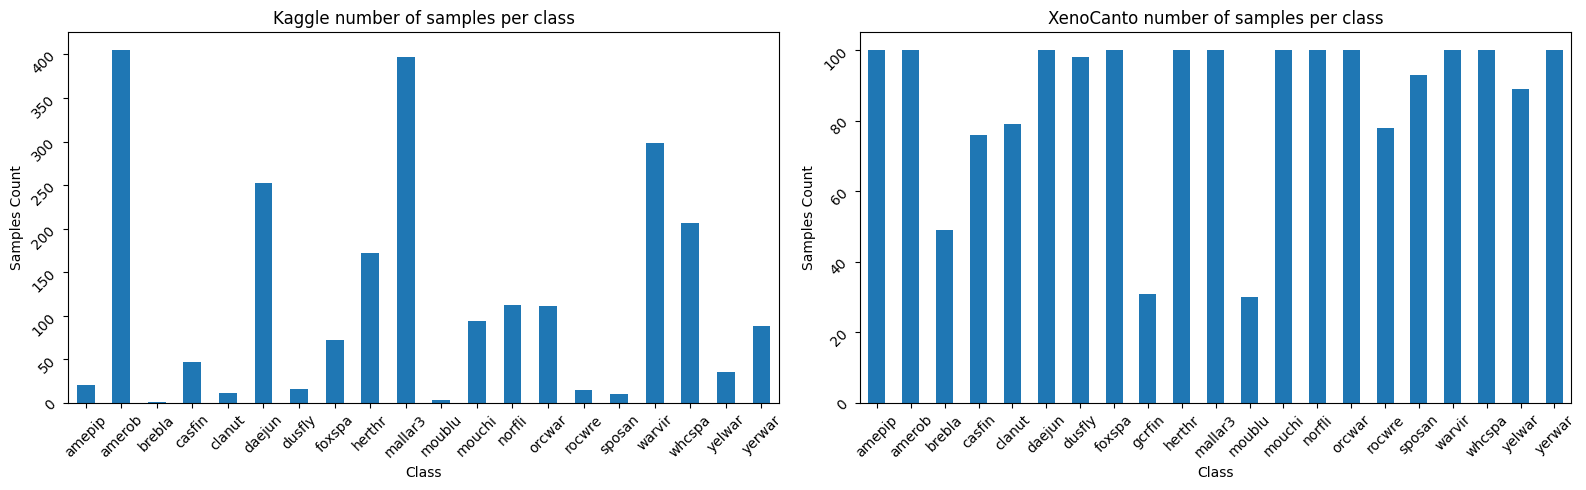

In [72]:
data_kaggle = pd.DataFrame.from_dict(data_dict["kaggle_extra"], "index").T
data_xeno = pd.DataFrame.from_dict(data_dict["xenoCanto"], "index").T
counts_kaggle = data_kaggle.count()
counts_xeno = data_xeno.count()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

counts_kaggle.plot(kind="bar", ax=axes[0])
axes[0].set_title("Kaggle number of samples per class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Samples Count")
axes[0].tick_params(rotation=45)

counts_xeno.plot(kind="bar", ax=axes[1])
axes[1].set_title("XenoCanto number of samples per class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Samples Count")
axes[1].tick_params(rotation=45)

plt.tight_layout()
plt.show()

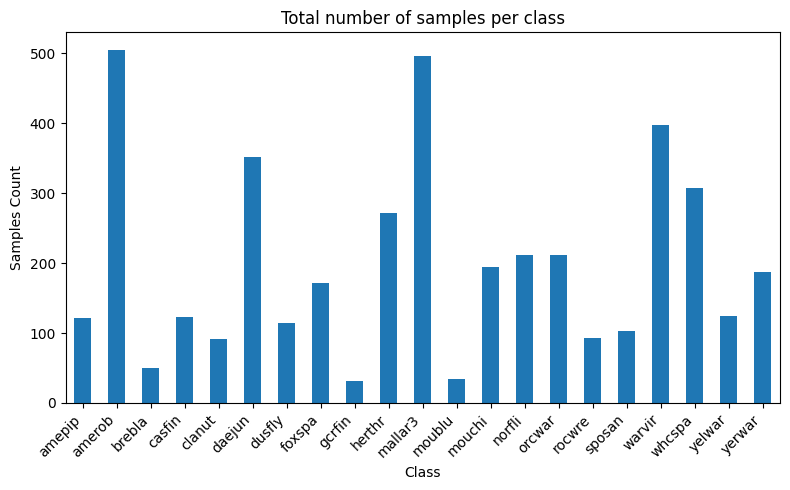

In [73]:
full_data = pd.concat([data_xeno, data_kaggle])
counts = full_data.count()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar")
plt.title("Total number of samples per class")
plt.xlabel("Class")
plt.ylabel("Samples Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()